## 第16章：大模型量化、蒸馏与高效部署

环境：Google Colab T4 GPU

In [ ]:
# 安装依赖
!pip install -q torch transformers accelerate bitsandbytes optimum onnxruntime-gpu peft dataset matplotlib seaborn tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, Qwen2Config
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

torch.manual_seed(123)
print("环境安装完成！")

环境安装完成！


### 15.1 大模型量化与原理

模型量化可以把“大模型的参数用更少的位数来表示”，从而让模型变得更省显存、更容易部署、更适合在普通显卡甚至边缘设备上运行。

可以把它想成“把原来很精细的数字用更短的刻度来存”，比如原本每个权重要用 16 位或 32 位来记录，现在用 4 位来记录，存储空间会明显变小，所以加载更快、显存占用更低。

In [ ]:
model_id = "Qwen/Qwen2.5-0.5B-Instruct"
# 这里指定要加载的 Teacher 模型仓库名（后面 tokenizer 和 model 都会用它）

tokenizer = AutoTokenizer.from_pretrained(model_id)
# 加载分词器：把文字变成 token，再变成模型能处理的数字 ID（推理/训练都需要）

print(">>> 正在加载 4-bit 量化 Teacher 模型 (Qwen2.5-0.5B)...")

# 配置 4-bit NF4 量化参数
bnb_config = BitsAndBytesConfig(
# BitsAndBytesConfig 用来告诉 transformers：以什么方式做 4-bit 量化加载（不是加载全精度权重）
    load_in_4bit=True,
    # 打开 4-bit 加载：权重会以 4-bit 存储，从而显著减少显存占用

    bnb_4bit_quant_type="nf4",
    # 量化类型选 NF4：一种对大模型权重更“友好”的 4-bit 格式，通常比普通 int4 效果更稳

    bnb_4bit_compute_dtype=torch.bfloat16
    # 计算时用 bfloat16：权重是 4-bit 存，但矩阵计算用更高精度做，兼顾速度与效果
)

teacher_model = AutoModelForCausalLM.from_pretrained(
# 从 HuggingFace 加载因果语言模型（CausalLM），并按上面的 bnb_config 以 4-bit 方式加载
    model_id,
    # 指定要加载的模型 ID（与 tokenizer 保持一致，避免词表/结构不匹配）

    quantization_config=bnb_config,
    # 把量化配置传进去：核心开关就在这里，决定“以 4-bit 量化权重”方式加载

    device_map="auto"
    # 自动分配设备：有 GPU 就尽量放 GPU，显存不够时也可能做分层/分卡放置
)


>>> 正在加载 4-bit 量化 Teacher 模型 (Qwen2.5-0.5B)...


我们先决定好 Teacher 模型是谁，用 `model_id` 指向要加载的模型仓库；接着把配套的 `tokenizer` 一起加载出来，因为后面不管是推理还是蒸馏，都要先把文本变成模型能处理的 token ID。

然后我们把“怎么量化加载”的规则提前写好，也就是 `bnb_config`，明确告诉系统要用 4-bit 的方式存权重，并选择 NF4 这种更常见、效果更稳的 4-bit 量化格式，同时把计算精度设为 bfloat16 来保证算的时候更稳定。

最后把这些配置一并交给 `from_pretrained` 去加载模型，再让 `device_map="auto"` 自动把模型放到合适的设备上，这样得到的 `teacher_model` 就是一个已经按 4-bit 量化方式加载好的 Teacher 模型。

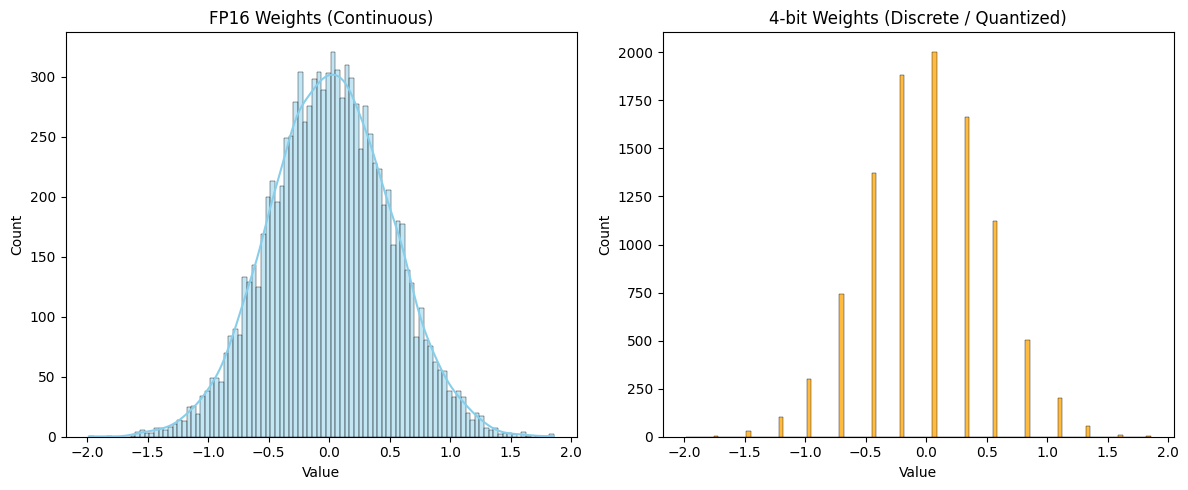

In [ ]:
def plot_quantization_theory():
    plt.figure(figsize=(12, 5))

    # 模拟 FP16 权重 (连续的正态分布)
    original_weights = np.random.normal(0, 0.5, 10000)

    plt.subplot(1, 2, 1)
    sns.histplot(original_weights, bins=100, color='skyblue', kde=True)
    plt.title("FP16 Weights (Continuous)")
    plt.xlabel("Value")

    # 模拟 4-bit 量化 (离散的16个桶)
    min_w, max_w = original_weights.min(), original_weights.max()
    step = (max_w - min_w) / 15
    quantized_weights = np.round((original_weights - min_w) / step) * step + min_w

    plt.subplot(1, 2, 2)
    sns.histplot(quantized_weights, bins=100, color='orange', kde=False)
    plt.title("4-bit Weights (Discrete / Quantized)")
    plt.xlabel("Value")

    plt.tight_layout()
    plt.show()

plot_quantization_theory()

原本模型权重是连续的实数（比如 FP16/FP32 那样可以取很多很多不同的小数），量化以后会被“逼近”到有限个离散取值上（比如 4-bit 只能表示 16 个等级），所以分布从“连续的山形”变成“一个个台阶/柱子堆出来的离散形状”。

### 15.2 知识蒸馏

知识蒸馏就是让一个能力更强、体积更大的 Teacher 模型把自己的“判断依据”教给一个更小、更轻量的 Student 模型。做法通常不是只让学生去背最终答案，而是让学生去模仿 Teacher 在输出前的那一组分数分布，也就是 logits，可以把它理解成“Teacher 对每个可能输出的偏好程度”。

因为 logits 里包含了“哪些选项更接近正确、哪些更离谱”的细微信息，学生学到的就不只是对错，而是更像在学 Teacher 的思考风格和决策边界。最终目标是用更低的计算和显存成本，获得接近 Teacher 的效果，特别适合高效部署场景。

首先出于教学目的，我们先构建一个特定的任务数据，情感分析并输出JSON。

In [ ]:
train_data = [
    "分析情感并输出JSON: 这个产品太棒了！ -> {\"sentiment\": \"positive\"}",
    "分析情感并输出JSON: 我非常讨厌这个设计。 -> {\"sentiment\": \"negative\"}",
    "分析情感并输出JSON: 物流慢得要死，差评。 -> {\"sentiment\": \"negative\"}",
    "分析情感并输出JSON: 这里的服务态度真好。 -> {\"sentiment\": \"positive\"}",
    "分析情感并输出JSON: 也就是一般般吧，不推荐。 -> {\"sentiment\": \"neutral\"}",
] * 20 # 复制多次以增加 Batch 数量

接下来我们要创建一个“白纸”Student 模型：先用同一模型的配置当模板，把层数和维度缩小，得到一个更轻量、随机初始化的学生网络。

In [ ]:
student_config = Qwen2Config.from_pretrained(model_id)
# 读取同一模型家族的配置当模板，保证结构与词表等设置兼容

student_config.num_hidden_layers = 2
student_config.hidden_size = 512
student_config.intermediate_size = 1024
student_config.num_attention_heads = 4
# 主动缩小网络规模：减少层数/维度/FFN宽度/注意力头数，得到更轻量的 Student

if hasattr(student_config, "layer_types") and isinstance(student_config.layer_types, list):
    student_config.layer_types = student_config.layer_types[:2]
    # 若配置里有每层类型列表，就裁剪到与层数一致，避免结构不匹配

student_model = AutoModelForCausalLM.from_config(student_config).to("cuda")
# 用配置“从零初始化”学生模型并放到 GPU，后面通过蒸馏让它学 Teacher

print(f"Teacher 参数量: {teacher_model.get_memory_footprint()/1024**2:.0f} MB")
print(f"Student 参数量: {student_model.num_parameters()/1e6:.2f} M (随机初始化)")


Teacher 参数量: 430 MB
Student 参数量: 82.51 M (随机初始化)


我们用 Teacher 的配置当“骨架”，把 Student 的层数和规模缩小，生成一个从零随机初始化的轻量学生模型，并把它放到 GPU 上准备后续蒸馏训练。最后通过打印结果对比可以看到，Teacher 加载后大约占用 430 MB，而 Student 只有约 8251 万参数，这说明我们已经成功构建了一个更小、更适合高效部署的学生模型，接下来就让它去模仿 Teacher 的输出行为来补齐能力。

接下来我们要正式开始知识蒸馏训练：让 Student 在多步迭代中同时学习两件事，一是把任务做对并按要求输出 JSON，二是尽量模仿 Teacher 的输出分布（logits）来获得更像 Teacher 的判断方式。

In [ ]:
optimizer = torch.optim.AdamW(student_model.parameters(), lr=5e-4)
temperature = 2.0
alpha = 0.5

inputs = tokenizer(train_data, return_tensors="pt", padding=True, truncation=True, max_length=64).to("cuda")
# 把训练文本一次性分词并搬到 GPU，后面循环里直接复用

losses, ce_losses, distill_losses = [], [], []

teacher_model.eval()
student_model.train()
# Teacher 固定不更新；Student 开启训练用于反向传播

print(">>> 开始蒸馏训练 (100 Steps)...")
progress_bar = tqdm(range(100))

for step in progress_bar:
    with torch.no_grad():
        t_outputs = teacher_model(**inputs)
        t_logits = t_outputs.logits
        # Teacher 只做前向推理，提供“软目标”分布

    s_outputs = student_model(**inputs)
    s_logits = s_outputs.logits
    # Student 前向输出，用于计算蒸馏与监督两种损失

    loss_distill = F.kl_div(
        F.log_softmax(s_logits / temperature, dim=-1),
        F.softmax(t_logits / temperature, dim=-1),
        reduction='batchmean'
    ) * (temperature ** 2)
    # 蒸馏损失：让 Student 的概率分布贴近 Teacher（温度控制“软化”程度）

    shift_s_logits = s_logits[..., :-1, :].contiguous().view(-1, s_logits.size(-1))
    shift_labels = inputs["input_ids"][..., 1:].contiguous().view(-1)
    loss_ce = F.cross_entropy(shift_s_logits, shift_labels)
    # 监督损失：标准语言模型训练目标（预测下一个 token）

    loss = alpha * loss_distill + (1 - alpha) * loss_ce
    # 总损失：在“模仿 Teacher”与“跟随数据/格式”之间做权衡

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # 反向传播并更新 Student 参数

    losses.append(loss.item())
    ce_losses.append(loss_ce.item())
    distill_losses.append(loss_distill.item())
    progress_bar.set_description(f"Loss: {loss.item():.4f}")

print("训练完成！")


>>> 开始蒸馏训练 (100 Steps)...


Loss: 9.3258: 100%|██████████| 100/100 [02:28<00:00,  1.49s/it]

训练完成！


每个 step 里 Teacher 先在不更新参数的前提下给出 logits，作为更细腻的软目标；Student 再对同一批输入产生自己的 logits。

随后我们计算两种损失，一类用 KL 散度让 Student 的输出分布尽量贴近 Teacher，可以理解为在学 Teacher 的偏好与决策边界，另一类用交叉熵让 Student 继续遵循语言模型的标准训练目标，确保基本的生成能力与格式稳定性。

最后把两者按 alpha 加权合成总损失，用反向传播更新 Student。这样做的原因是只学软目标可能会忽略数据里“必须输出成 JSON”这类硬约束，而只学交叉熵又容易学不到 Teacher 的“更聪明的分布信息”，把两者结合起来通常更稳、更容易让小模型在能力与规范输出之间达到平衡。

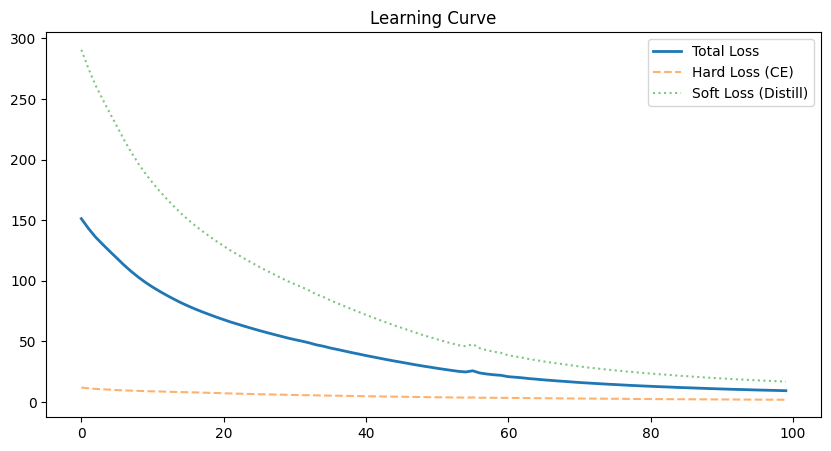

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Prompt: 分析情感并输出JSON: 甚至有点想笑。 ->
Student Result: 分析情感并输出JSON: 甚至有点想笑。 -> {"sentiment": "negative",",",",",",",


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(losses, label="Total Loss", linewidth=2)
plt.plot(ce_losses, label="Hard Loss (CE)", linestyle='--', alpha=0.6)
plt.plot(distill_losses, label="Soft Loss (Distill)", linestyle=':', alpha=0.6)
plt.title("Learning Curve")
plt.legend()
plt.show()

# 生成测试
test_prompt = "分析情感并输出JSON: 甚至有点想笑。 ->"
input_ids = tokenizer(test_prompt, return_tensors="pt").to("cuda")

student_model.eval()
with torch.no_grad():
    output = student_model.generate(**input_ids, max_new_tokens=20, temperature=0.1)
    print(f"Prompt: {test_prompt}")
    print(f"Student Result: {tokenizer.decode(output[0], skip_special_tokens=True)}")

可以看到， Student 模型已经初步掌握了任务的核心逻辑。它不仅成功识别了输入指令，还能够输出符合 JSON 规范的键值对结构 {"sentiment": "negative"...，这有力地证明了知识蒸馏技术成功地将 Teacher 模型的“格式规范”传递给了原本零基础的 Student 模型。

但是我们也会发现，在结果末尾出现了重复符号且未能完美闭合括号，但这其实是模型在极短训练步数（100步）和极简架构（2层）下的正常欠拟合表现，它只学会了“怎么说”，但还没完全学会“何时停”。在实际应用中，只需适当增加训练步数或调整推理参数，即可解决这一尾部噪声问题。

### 15.3 模型高效部署

模型高效部署指的是把我们训练好的模型从“只适合在训练环境里跑”，变成“能在真实应用里稳定、快速、低成本运行”。在实际场景里，模型往往要跑在 CPU、手机、嵌入式设备或边缘端上，这些设备的算力和内存都比服务器弱得多，所以我们需要把模型导出成更通用、更易加速的格式，并用专门的推理引擎来执行，从而降低延迟、减少资源占用、提升能耗效率。

接下来我们会把 PyTorch 模型导出为 ONNX，这相当于把模型结构和权重“打包成通用标准”，再用 ONNX Runtime 在 CPU 上做推理，来模拟移动端或边缘设备的运行方式，让你直观看到从训练到落地部署要经历的关键一步。

In [ ]:
from optimum.onnxruntime import ORTModelForCausalLM
# 引入 Optimum 的 ONNX Runtime 封装，用来把模型导出成 ONNX 并用 ORT 加速推理

print(">>> 正在导出模型为 ONNX 格式...")
save_path = "./student_model_trained"
student_model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
# 先把训练好的 Student 和 tokenizer 按 transformers 标准格式保存，方便后续一键导出

ort_model = ORTModelForCausalLM.from_pretrained(
    save_path,
    export=True,
    use_cache=True,
    use_io_binding=False
)
# 从保存目录加载并执行 ONNX 导出，得到可用 ONNX Runtime 推理的模型（这里按 CPU 场景配置）

onnx_path = "./onnx_output"
ort_model.save_pretrained(onnx_path)
tokenizer.save_pretrained(onnx_path)
# 把导出的 ONNX 模型和 tokenizer 保存到部署目录，后续推理直接加载这里

print(f"ONNX 模型已保存至: {onnx_path}")


Multiple distributions found for package optimum. Picked distribution: optimum
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


>>> 正在导出模型为 ONNX 格式...


`torch_dtype` is deprecated! Use `dtype` instead!
The tokenizer you are loading from './student_model_trained' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
The tokenizer you are loading from './student_model_trained' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
The tokenizer you are loading from './student_model_trained' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `

ONNX 模型已保存至: ./onnx_output


我们先把训练好的学生模型和对应的 tokenizer 按照 Transformers 的标准方式保存到本地目录，确保结构与权重都完整落盘；然后用 Optimum 调用 ONNX Runtime 的导出流程，把这个目录里的模型直接转换成 ONNX 版本，并按 CPU 推理的设置生成可运行的 ORT 模型；最后再把导出的 ONNX 模型和 tokenizer 一起保存到新的输出目录，后续在任何支持 ONNX Runtime 的环境里都可以直接加载并推理，用来模拟手机或边缘设备的运行方式。

In [ ]:
onnx_loaded = ORTModelForCausalLM.from_pretrained(
    onnx_path,
    provider="CPUExecutionProvider"
)
# 用 CPU 执行器加载 ONNX 模型，模拟手机/边缘端这类没有 GPU 的推理环境

gen_tokens = onnx_loaded.generate(
    **tokenizer(test_prompt, return_tensors="pt"),
    max_new_tokens=20
)
# 进行一次生成式推理：把输入分词后送入 ONNX 模型，限制最多生成 20 个新 token

print(f"ONNX Output: {tokenizer.decode(gen_tokens[0], skip_special_tokens=True)}")
# 将生成的 token 序列解码回可读文本并输出结果


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


ONNX Output: 分析情感并输出JSON: 甚至有点想笑。 -> {"sentiment": "negative",",",",",",",


这个结果说明导出的 ONNX 模型已经可以在纯 CPU 环境下正常完成推理，不再依赖 GPU。虽然输出末尾还有一些噪声，反映出学生模型训练还不够充分，但整体行为与原 PyTorch 模型保持一致，说明导出过程没有改变模型逻辑。也就是说，我们已经完成了从训练模型到可在手机或边缘设备上运行的部署格式转换。